In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from datetime import datetime as dt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime as dt
import datetime as dt
from datetime import datetime
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score, roc_curve
# Load datasets
df = pd.read_csv('fraudTest.csv')
tdf = pd.read_csv('fraudTrain.csv')



In [2]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
tdf.head()


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [9]:
tdf.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [13]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [15]:
df.isnull().any()

Unnamed: 0               False
trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
dtype: bool

In [17]:
tdf.isnull().any()

Unnamed: 0               False
trans_date_trans_time    False
cc_num                   False
merchant                 False
category                 False
amt                      False
first                    False
last                     False
gender                   False
street                   False
city                     False
state                    False
zip                      False
lat                      False
long                     False
city_pop                 False
job                      False
dob                      False
trans_num                False
unix_time                False
merch_lat                False
merch_long               False
is_fraud                 False
dtype: bool

In [19]:
df.duplicated().any()

False

In [21]:
tdf.duplicated().any()

False

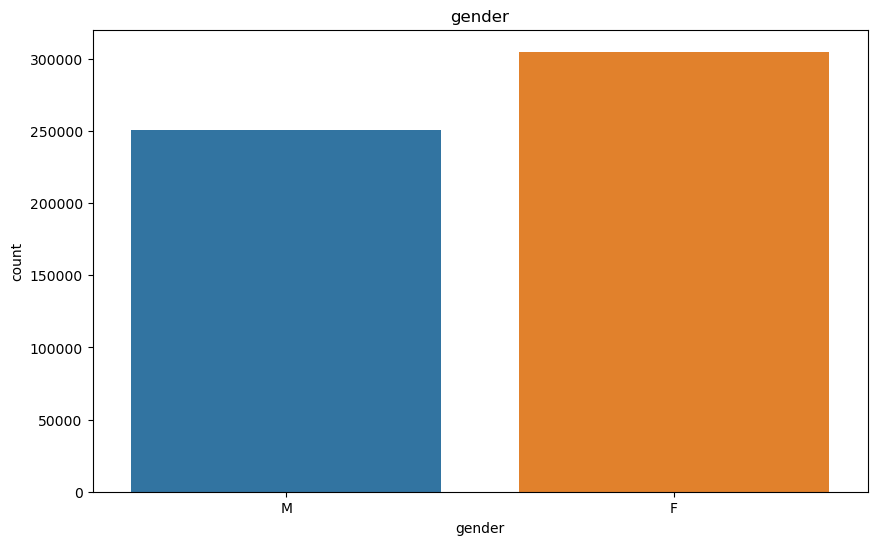

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=df)
plt.title('gender')
plt.show()


In [25]:
df["gender"].value_counts()

gender
F    304886
M    250833
Name: count, dtype: int64

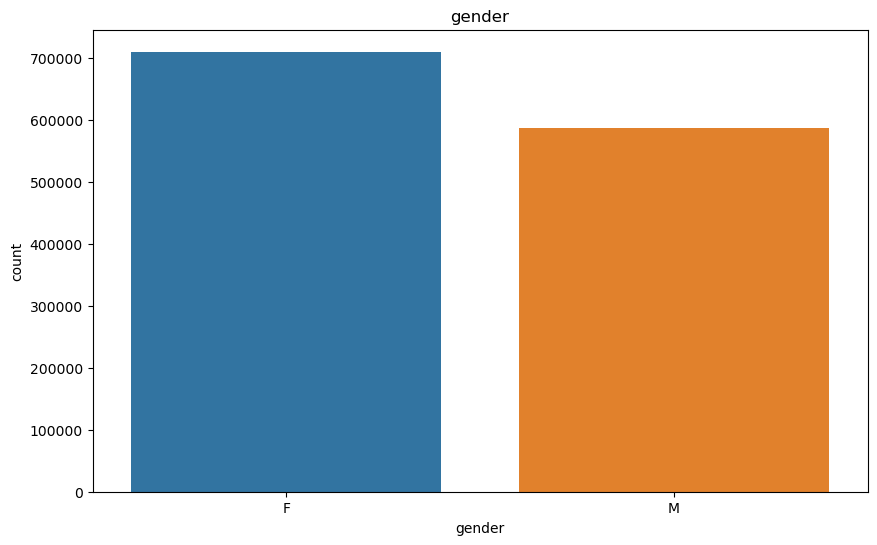

In [27]:
plt.figure(figsize=(10, 6))
sns.countplot(x='gender', data=tdf)
plt.title('gender')
plt.show()

In [29]:
tdf["gender"].value_counts()

gender
F    709863
M    586812
Name: count, dtype: int64

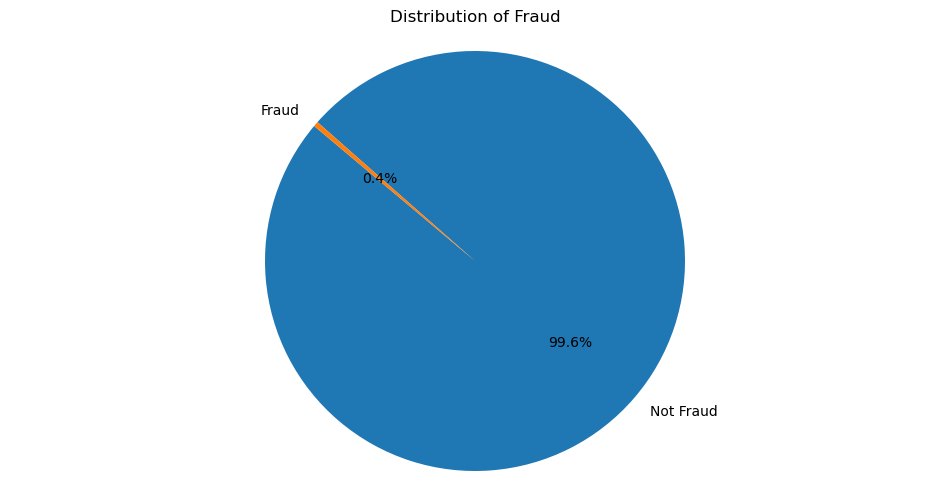

In [31]:
plt.figure(figsize = (12,6))
labels = ["Not Fraud","Fraud"]
values = df.is_fraud.value_counts()
plt.pie(values,labels = labels,autopct = "%1.1f%%",startangle = 140)
plt.title("Distribution of Fraud")
plt.axis("equal")
plt.show()

In [33]:
df["is_fraud"].value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

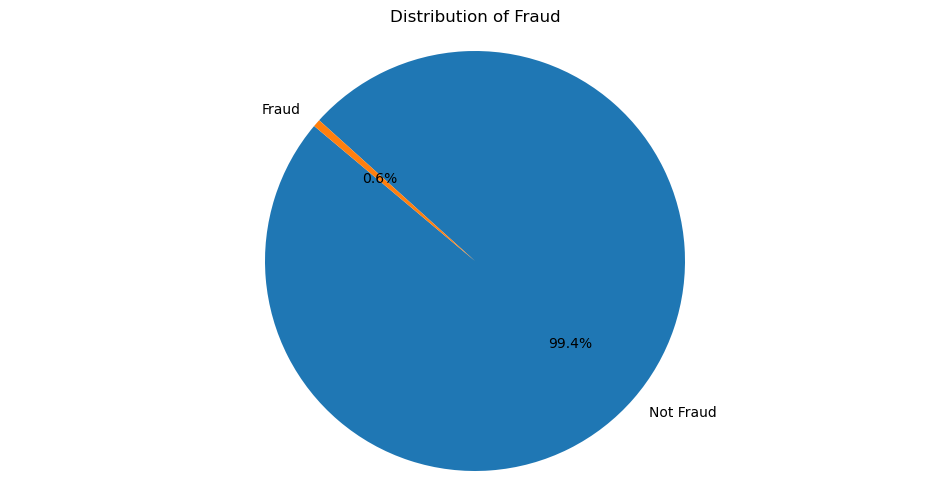

In [35]:
plt.figure(figsize = (12,6))
labels = ["Not Fraud","Fraud"]
values = tdf.is_fraud.value_counts()
plt.pie(values,labels = labels,autopct = "%1.1f%%",startangle = 140)
plt.title("Distribution of Fraud")
plt.axis("equal")
plt.show()

In [37]:
tdf["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

<Axes: xlabel='is_fraud'>

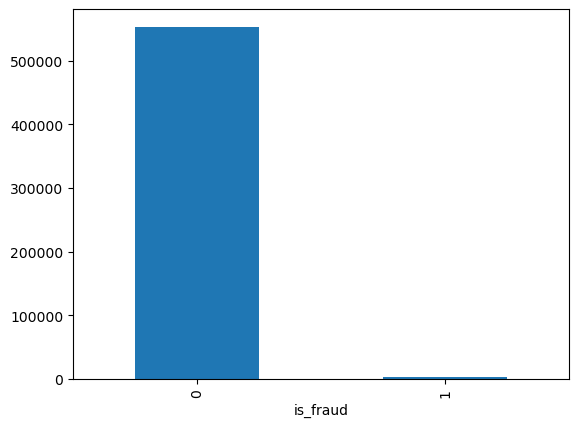

In [39]:
df.groupby("is_fraud").count()["cc_num"].plot(kind = "bar")

<Axes: xlabel='is_fraud'>

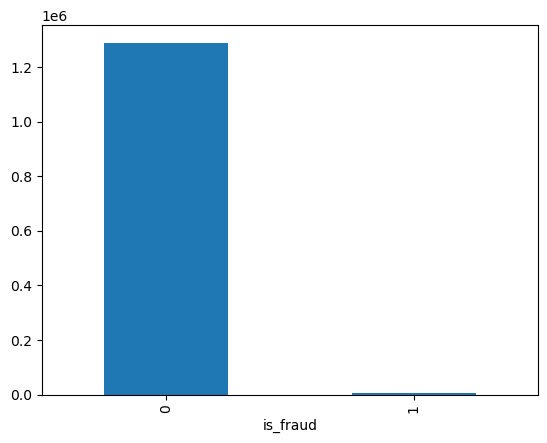

In [41]:
tdf.groupby("is_fraud").count()["cc_num"].plot(kind = "bar")

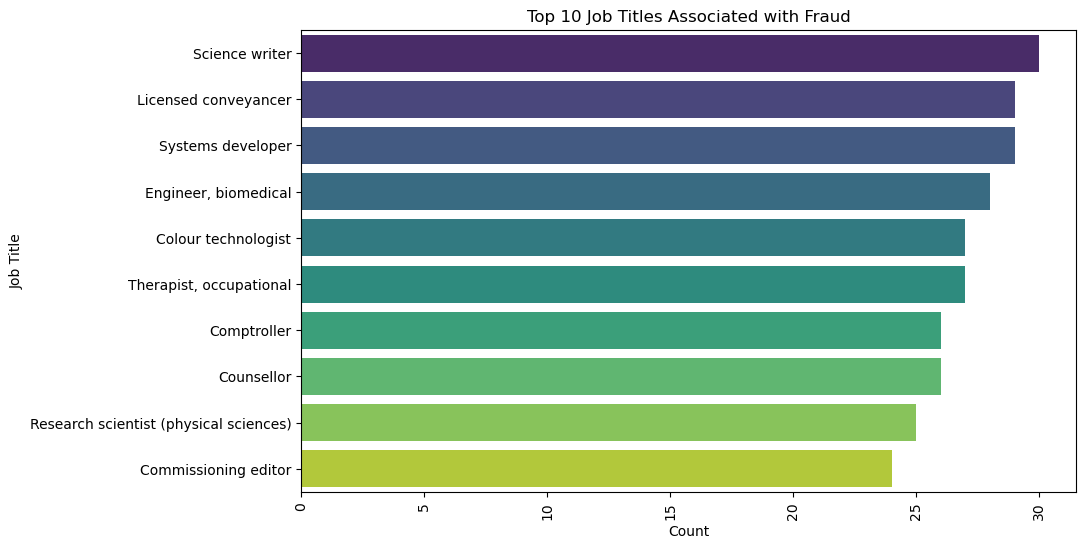

In [43]:
# Extract top 10 job titles associated with fraud and their counts
fraud_job_title = df[df["is_fraud"] == 1]["job"].value_counts().head(10)


# Convert to a DataFrame for easier plotting
fraud_job_title_df = fraud_job_title.reset_index()
fraud_job_title_df.columns = ['job', 'count']

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=fraud_job_title_df, x="count", y="job",palette="viridis",dodge=False)
plt.title('Top 10 Job Titles Associated with Fraud')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.xticks(rotation=90)
plt.show()

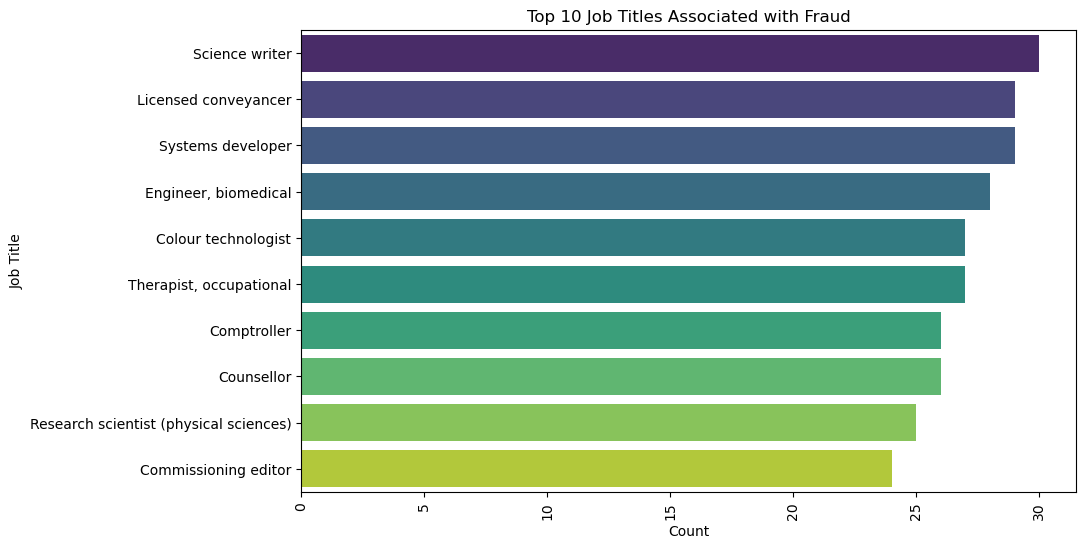

In [45]:
# Extract top 10 job titles associated with fraud and their counts
fraud_job_title = tdf[tdf["is_fraud"] == 1]["job"].value_counts().head(10)


# Convert to a DataFrame for easier plotting
fraud_job_title_tdf = fraud_job_title.reset_index()
fraud_job_title_tdf.columns = ['job', 'count']

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=fraud_job_title_df, x="count", y="job",palette="viridis",dodge=False)
plt.title('Top 10 Job Titles Associated with Fraud')
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.xticks(rotation=90)
plt.show()

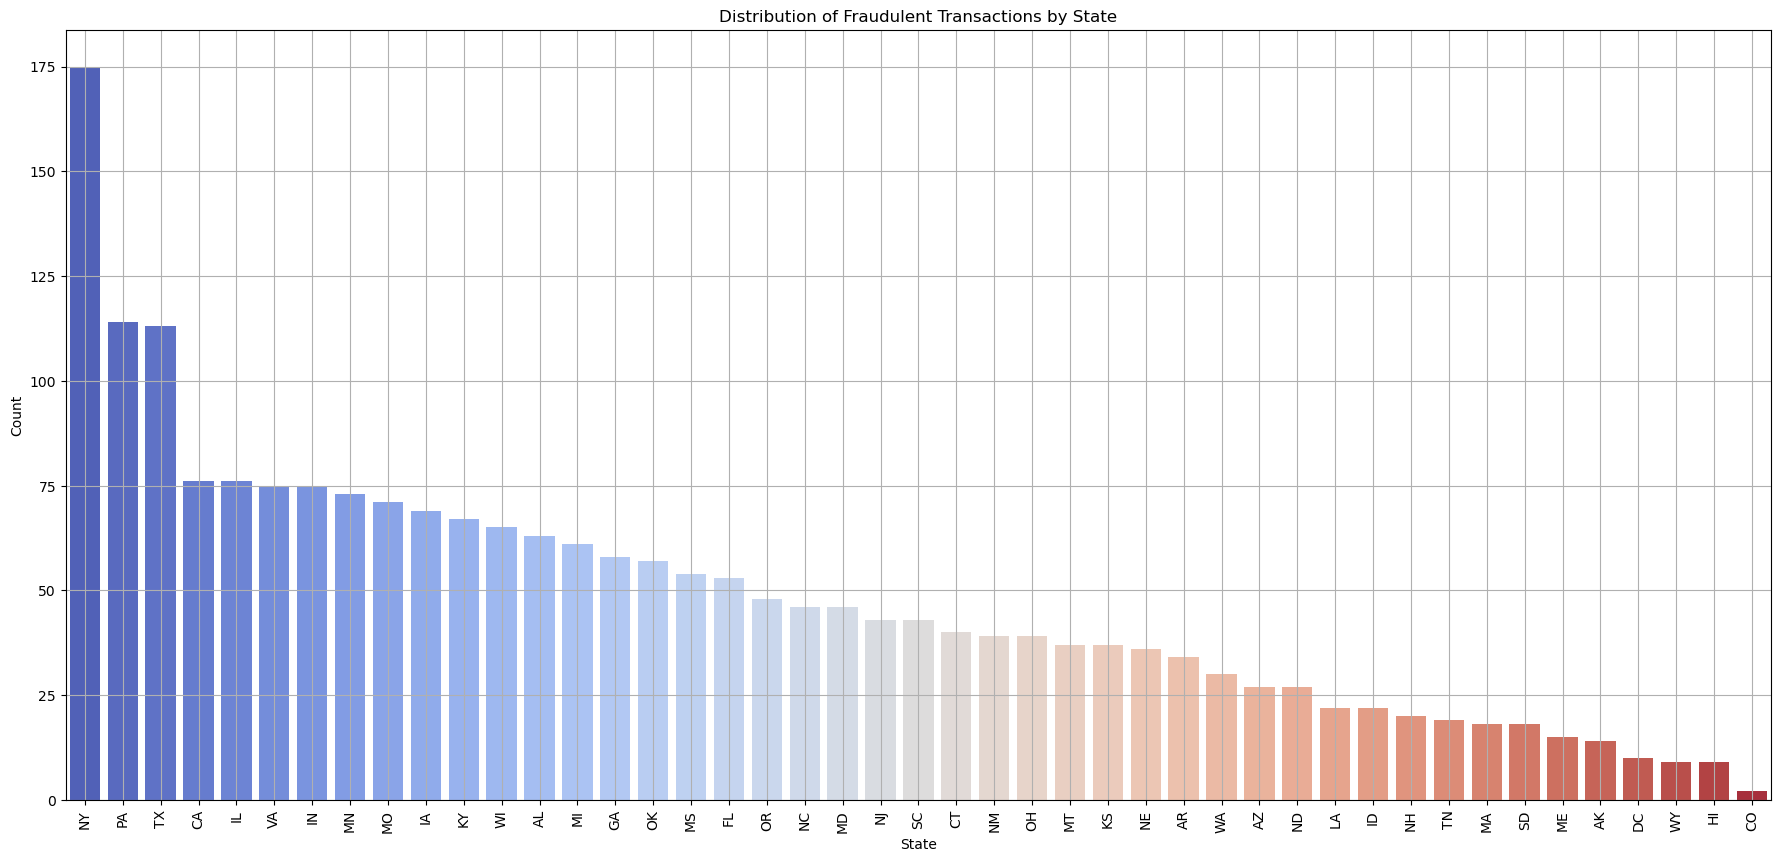

In [47]:
fraud_by_state = df[df['is_fraud'] == 1]['state'].value_counts()
plt.figure(figsize=(22, 10))
sns.barplot(x=fraud_by_state.index, y=fraud_by_state.values, palette='coolwarm')
plt.xlabel('State')
plt.ylabel('Count')
plt.title('Distribution of Fraudulent Transactions by State')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

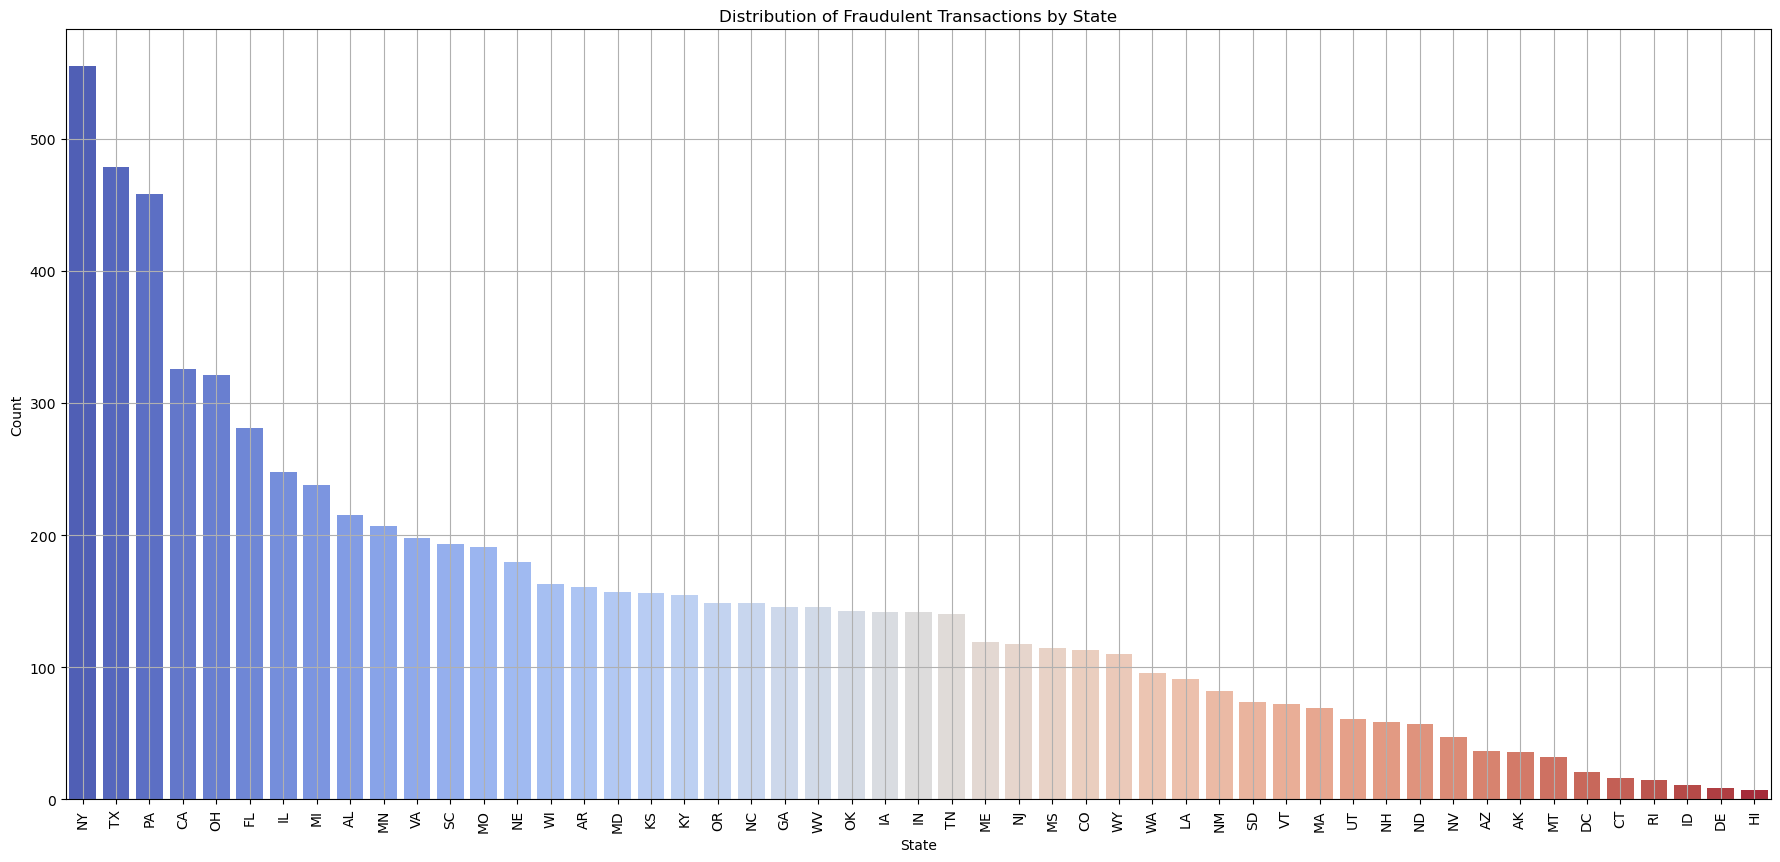

In [49]:
fraud_by_state = tdf[tdf['is_fraud'] == 1]['state'].value_counts()
plt.figure(figsize=(22, 10))
sns.barplot(x=fraud_by_state.index, y=fraud_by_state.values, palette='coolwarm')
plt.xlabel('State')
plt.ylabel('Count')
plt.title('Distribution of Fraudulent Transactions by State')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [51]:
df["category"].value_counts()

category
gas_transport     56370
grocery_pos       52553
home              52345
shopping_pos      49791
kids_pets         48692
shopping_net      41779
entertainment     40104
personal_care     39327
food_dining       39268
health_fitness    36674
misc_pos          34574
misc_net          27367
grocery_net       19426
travel            17449
Name: count, dtype: int64

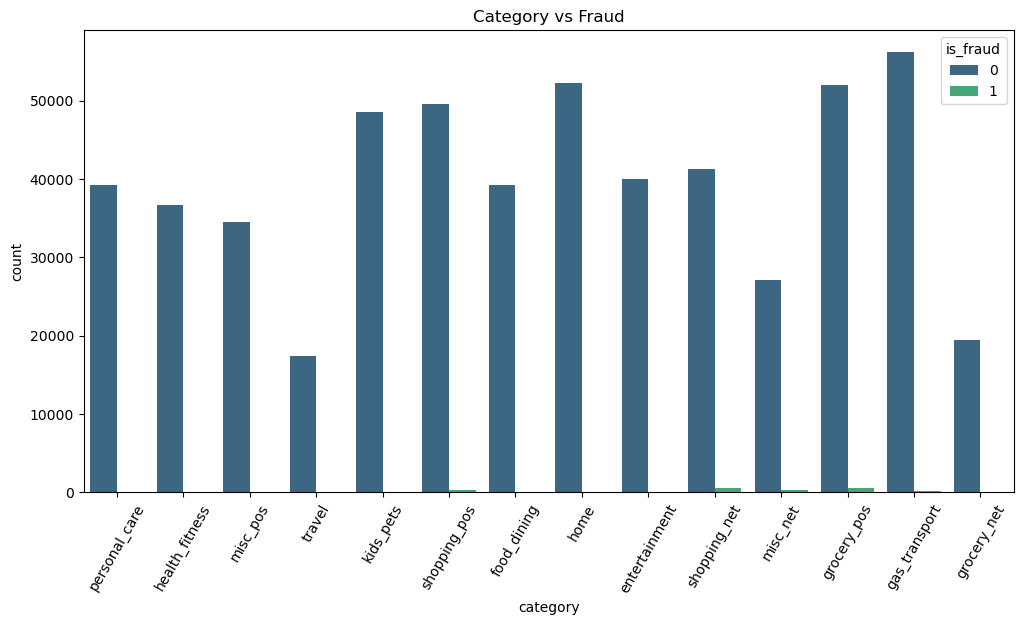

In [53]:
df['category'] = df['category'].astype(str)

# Ensure the 'is_fraud' column is of type string for plotting
df['is_fraud'] = df['is_fraud'].astype(str)

# Plot the data
plt.figure(figsize=(12,6))
sns.countplot(x='category', hue='is_fraud', data=df, palette='viridis')
plt.title('Category vs Fraud')
plt.xticks(rotation=60)
plt.show()

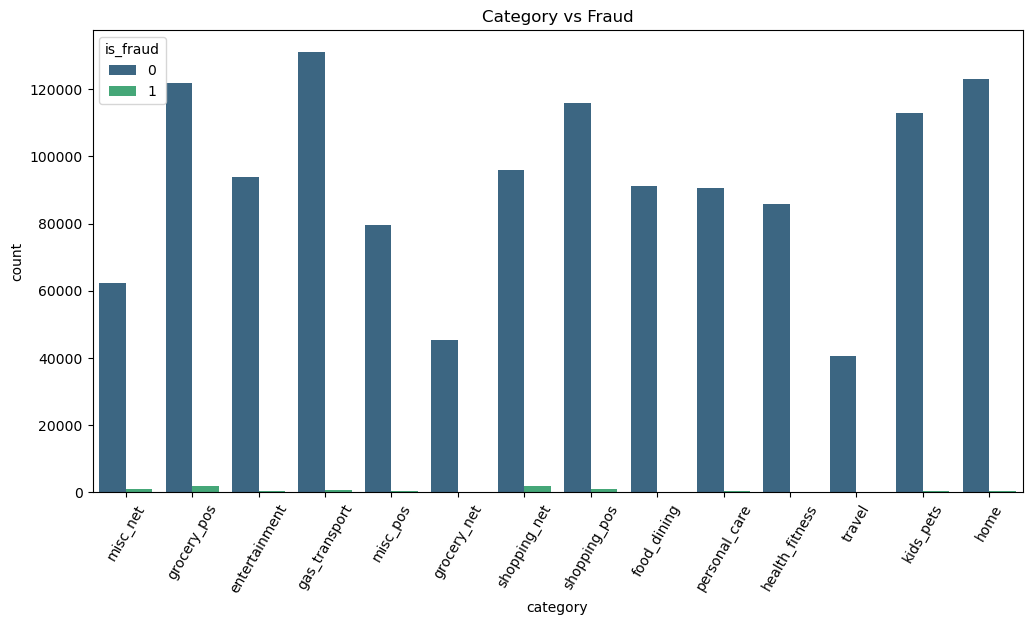

In [55]:
tdf['category'] = tdf['category'].astype(str)

# Ensure the 'is_fraud' column is of type string for plotting
tdf['is_fraud'] = tdf['is_fraud'].astype(str)

# Plot the data
plt.figure(figsize=(12,6))
sns.countplot(x='category', hue='is_fraud', data=tdf, palette='viridis')
plt.title('Category vs Fraud')
plt.xticks(rotation=60)
plt.show()

In [57]:
tdf["category"].value_counts()

category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64

In [59]:
df["dob"] = pd.to_datetime(df["dob"])


In [61]:
tdf["dob"] = pd.to_datetime(tdf["dob"])

In [63]:
# Convert the 'dob' column to datetime format
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')

# Extract the year from the 'dob' column
df["dob"] = df["dob"].dt.year

# Calculate the age by subtracting the birth year from the current year
df['dob'] = datetime.now().year - df['dob']

# Rename the 'dob' column to 'age'
df = df.rename(columns={"dob": "age"})

# Display the DataFrame
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,age,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,56,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",34,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",54,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,37,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,69,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,...,40.4931,-91.8912,519,Town planner,58,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
555715,555715,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,...,29.0393,-95.4401,28739,Futures trader,25,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
555716,555716,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,...,46.1966,-118.9017,3684,Musician,43,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
555717,555717,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,...,44.6255,-116.4493,129,Cartographer,59,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


In [65]:
# Convert the 'dob' column to datetime format
tdf['dob'] = pd.to_datetime(tdf['dob'], errors='coerce')

# Extract the year from the 'dob' column
tdf["dob"] = tdf["dob"].dt.year

# Calculate the age by subtracting the birth year from the current year
tdf['dob'] = datetime.now().year - tdf['dob']

# Rename the 'dob' column to 'age'
tdf = tdf.rename(columns={"dob": "age"})

# Display the DataFrame
tdf

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,age,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",36,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,46,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,62,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,57,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,38,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,63,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",45,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,57,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,44,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [67]:
numeric_columns = df.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

In [69]:
numeric_columns = tdf.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
categorical_columns = tdf.select_dtypes(include=['object']).columns.tolist()

In [193]:
print(numeric_columns)
print(categorical_columns)

['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'trans_num']


In [71]:
encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,age,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,0,2291163933867244,319,10,2.86,151,115,1,341,...,33.9659,-80.9355,333497,275,56,98699,1371816865,33.986391,-81.200714,0
1,1,1,3573030041201292,591,10,29.84,163,457,0,354,...,40.3207,-110.4360,302,392,34,108785,1371816873,39.450498,-109.960431,0
2,2,2,3598215285024754,611,5,41.28,24,249,0,865,...,40.6729,-73.5365,34496,259,54,433979,1371816893,40.495810,-74.196111,0
3,3,3,3591919803438423,222,9,60.05,42,457,1,320,...,28.5697,-80.8191,54767,407,37,71993,1371816915,28.812398,-80.883061,0
4,4,4,3526826139003047,292,13,3.19,247,261,1,548,...,44.2529,-85.0170,1126,196,69,190585,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,555714,544755,30560609640617,507,5,43.77,235,315,1,531,...,40.4931,-91.8912,519,460,58,336391,1388534347,39.946837,-91.333331,0
555715,555715,544756,3556613125071656,264,7,111.84,171,424,1,540,...,29.0393,-95.4401,28739,198,25,70372,1388534349,29.661049,-96.186633,0
555716,555716,544757,6011724471098086,496,7,86.88,18,239,0,126,...,46.1966,-118.9017,3684,294,43,235088,1388534355,46.658340,-119.715054,0
555717,555717,544758,4079773899158,75,13,7.99,111,342,1,663,...,44.6255,-116.4493,129,58,59,43546,1388534364,44.470525,-117.080888,0


In [199]:
numeric_columns = tdf.select_dtypes(include=['int64', 'int32', 'float64']).columns.tolist()
categorical_columns = tdf.select_dtypes(include=['object']).columns.tolist()

In [73]:
encoder = LabelEncoder()
for col in categorical_columns:
    tdf[col] = encoder.fit_transform(tdf[col])
tdf

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,age,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,0,2703186189652095,514,8,4.97,162,18,0,568,...,36.0788,-81.1781,3495,370,36,56438,1325376018,36.011293,-82.048315,0
1,1,1,630423337322,241,4,107.23,309,157,0,435,...,48.8878,-118.2105,149,428,46,159395,1325376044,49.159047,-118.186462,0
2,2,2,38859492057661,390,0,220.11,115,381,1,602,...,42.1808,-112.2620,4154,307,62,818703,1325376051,43.150704,-112.154481,0
3,3,3,3534093764340240,360,2,45.00,163,463,1,930,...,46.2306,-112.1138,1939,328,57,544575,1325376076,47.034331,-112.561071,0
4,4,4,375534208663984,297,9,41.96,336,149,1,418,...,38.4207,-79.4629,99,116,38,831111,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,1274786,30263540414123,499,0,15.56,121,332,1,154,...,37.7175,-112.4777,258,215,63,344658,1371816728,36.841266,-111.690765,0
1296671,1296671,1274787,6011149206456997,2,1,51.70,160,463,1,856,...,39.2667,-77.5101,100,360,45,199896,1371816739,38.906881,-78.246528,0
1296672,1296672,1274788,3514865930894695,599,1,105.93,74,67,1,158,...,32.9396,-105.8189,899,308,57,366013,1371816752,33.619513,-105.130529,0
1296673,1296673,1274789,2720012583106919,509,1,74.90,179,304,1,433,...,43.3526,-102.5411,1126,485,44,1086299,1371816816,42.788940,-103.241160,0


In [75]:
df.drop(columns = "Unnamed: 0",inplace = True)

In [77]:
tdf.drop(columns = "Unnamed: 0",inplace = True)

In [79]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,age,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2291163933867244,319,10,2.86,151,115,1,341,157,...,33.9659,-80.9355,333497,275,56,98699,1371816865,33.986391,-81.200714,0
1,1,3573030041201292,591,10,29.84,163,457,0,354,16,...,40.3207,-110.4360,302,392,34,108785,1371816873,39.450498,-109.960431,0
2,2,3598215285024754,611,5,41.28,24,249,0,865,61,...,40.6729,-73.5365,34496,259,54,433979,1371816893,40.495810,-74.196111,0
3,3,3591919803438423,222,9,60.05,42,457,1,320,764,...,28.5697,-80.8191,54767,407,37,71993,1371816915,28.812398,-80.883061,0
4,4,3526826139003047,292,13,3.19,247,261,1,548,247,...,44.2529,-85.0170,1126,196,69,190585,1371816917,44.959148,-85.884734,0


In [81]:
tdf.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,age,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2703186189652095,514,8,4.97,162,18,0,568,526,...,36.0788,-81.1781,3495,370,36,56438,1325376018,36.011293,-82.048315,0
1,1,630423337322,241,4,107.23,309,157,0,435,612,...,48.8878,-118.2105,149,428,46,159395,1325376044,49.159047,-118.186462,0
2,2,38859492057661,390,0,220.11,115,381,1,602,468,...,42.1808,-112.2620,4154,307,62,818703,1325376051,43.150704,-112.154481,0
3,3,3534093764340240,360,2,45.00,163,463,1,930,84,...,46.2306,-112.1138,1939,328,57,544575,1325376076,47.034331,-112.561071,0
4,4,375534208663984,297,9,41.96,336,149,1,418,216,...,38.4207,-79.4629,99,116,38,831111,1325376186,38.674999,-78.632459,0


In [83]:
models = {
    
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
}

In [85]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:20]

y_train=df.iloc[:,21]

X_test=tdf


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)



In [87]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [89]:
classifier = RandomForestClassifier(criterion='entropy', random_state=0)

In [91]:
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', random_state=0)

In [93]:
y_pred= classifier.predict(X_test)

In [95]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166062
           1       0.95      0.42      0.58       654

    accuracy                           1.00    166716
   macro avg       0.97      0.71      0.79    166716
weighted avg       1.00      1.00      1.00    166716



In [97]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:20]

y_train=df.iloc[:,21]

X_test=tdf


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)

In [99]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [101]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

In [103]:
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [105]:
y_pred= classifier.predict(X_test)

In [107]:
from sklearn.metrics import classification_report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166050
           1       0.98      0.55      0.70       666

    accuracy                           1.00    166716
   macro avg       0.99      0.77      0.85    166716
weighted avg       1.00      1.00      1.00    166716



In [125]:
df

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,age,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2291163933867244,319,10,2.86,151,115,1,341,157,...,33.9659,-80.9355,333497,275,56,98699,1371816865,33.986391,-81.200714,0
1,1,3573030041201292,591,10,29.84,163,457,0,354,16,...,40.3207,-110.4360,302,392,34,108785,1371816873,39.450498,-109.960431,0
2,2,3598215285024754,611,5,41.28,24,249,0,865,61,...,40.6729,-73.5365,34496,259,54,433979,1371816893,40.495810,-74.196111,0
3,3,3591919803438423,222,9,60.05,42,457,1,320,764,...,28.5697,-80.8191,54767,407,37,71993,1371816915,28.812398,-80.883061,0
4,4,3526826139003047,292,13,3.19,247,261,1,548,247,...,44.2529,-85.0170,1126,196,69,190585,1371816917,44.959148,-85.884734,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,544755,30560609640617,507,5,43.77,235,315,1,531,443,...,40.4931,-91.8912,519,460,58,336391,1388534347,39.946837,-91.333331,0
555715,544756,3556613125071656,264,7,111.84,171,424,1,540,401,...,29.0393,-95.4401,28739,198,25,70372,1388534349,29.661049,-96.186633,0
555716,544757,6011724471098086,496,7,86.88,18,239,0,126,104,...,46.1966,-118.9017,3684,294,43,235088,1388534355,46.658340,-119.715054,0
555717,544758,4079773899158,75,13,7.99,111,342,1,663,476,...,44.6255,-116.4493,129,58,59,43546,1388534364,44.470525,-117.080888,0


In [127]:
tdf

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,age,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2703186189652095,514,8,4.97,162,18,0,568,526,...,36.0788,-81.1781,3495,370,36,56438,1325376018,36.011293,-82.048315,0
1,1,630423337322,241,4,107.23,309,157,0,435,612,...,48.8878,-118.2105,149,428,46,159395,1325376044,49.159047,-118.186462,0
2,2,38859492057661,390,0,220.11,115,381,1,602,468,...,42.1808,-112.2620,4154,307,62,818703,1325376051,43.150704,-112.154481,0
3,3,3534093764340240,360,2,45.00,163,463,1,930,84,...,46.2306,-112.1138,1939,328,57,544575,1325376076,47.034331,-112.561071,0
4,4,375534208663984,297,9,41.96,336,149,1,418,216,...,38.4207,-79.4629,99,116,38,831111,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1274786,30263540414123,499,0,15.56,121,332,1,154,330,...,37.7175,-112.4777,258,215,63,344658,1371816728,36.841266,-111.690765,0
1296671,1274787,6011149206456997,2,1,51.70,160,463,1,856,813,...,39.2667,-77.5101,100,360,45,199896,1371816739,38.906881,-78.246528,0
1296672,1274788,3514865930894695,599,1,105.93,74,67,1,158,346,...,32.9396,-105.8189,899,308,57,366013,1371816752,33.619513,-105.130529,0
1296673,1274789,2720012583106919,509,1,74.90,179,304,1,433,471,...,43.3526,-102.5411,1126,485,44,1086299,1371816816,42.788940,-103.241160,0


In [271]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

In [273]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [275]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Now apply SelectKBest with Chi-Square test
k_best_features = SelectKBest(score_func=chi2, k=2)  # Select top 2 features

# Fit the SelectKBest model and transform X to get selected features
X_best = k_best_features.fit_transform(X_scaled, y)

# Check the selected features
print("Selected features shape:", X_best.shape)

Selected features shape: (555719, 2)


In [277]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:20]

y_train=df.iloc[:,21]

X_test=tdf


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)

In [279]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [281]:
classifier = RandomForestClassifier(criterion='entropy', random_state=0)

In [283]:
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', random_state=0)

In [285]:
y_pred= classifier.predict(X_test)

In [287]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166086
           1       0.96      0.58      0.73       630

    accuracy                           1.00    166716
   macro avg       0.98      0.79      0.86    166716
weighted avg       1.00      1.00      1.00    166716



In [301]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:20]

y_train=df.iloc[:,21]

X_test=tdf


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)


In [303]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [305]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

In [307]:
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [309]:
y_pred= classifier.predict(X_test)

In [311]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166082
           1       0.99      0.77      0.87       634

    accuracy                           1.00    166716
   macro avg       0.99      0.89      0.93    166716
weighted avg       1.00      1.00      1.00    166716



In [327]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [329]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:20]

y_train=df.iloc[:,21]

X_test=tdf


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)

In [331]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [333]:
classifier = RandomForestClassifier(criterion='entropy', random_state=0)

In [335]:
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', random_state=0)

In [128]:
y_pred= classifier.predict(X_test)

In [136]:


print('\nClassification Report:')
print(classification_report(y_test, y_pred))

AUC-ROC Score: 0.7767

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166080
           1       0.98      0.55      0.71       636

    accuracy                           1.00    166716
   macro avg       0.99      0.78      0.85    166716
weighted avg       1.00      1.00      1.00    166716



In [129]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [131]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:20]

y_train=df.iloc[:,21]

X_test=tdf


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)

In [133]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [135]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

In [137]:
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [141]:
y_pred= classifier.predict(X_test)

In [143]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166064
           1       0.99      0.88      0.93       652

    accuracy                           1.00    166716
   macro avg       1.00      0.94      0.97    166716
weighted avg       1.00      1.00      1.00    166716



In [125]:
y_pred= classifier.predict(X_test)

In [190]:
from sklearn.model_selection import cross_val_score

In [193]:
from sklearn.model_selection import GridSearchCV

In [216]:
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}


In [218]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:20]

y_train=df.iloc[:,21]

X_test=tdf


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)

In [220]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [222]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)

In [224]:
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [226]:
y_pred= classifier.predict(X_test)

In [247]:
grid_search = GridSearchCV(estimator=knn_classifier, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X, y)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 5, 7],
                         'weights': ['uniform', 'distance']},
             verbose=2)

In [248]:
# Print the best parameters and the best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

Best parameters: {'algorithm': 'auto', 'n_neighbors': 7, 'weights': 'distance'}
Best cross-validation score: 0.9908119070107595


In [249]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166077
           1       0.97      0.79      0.87       639

    accuracy                           1.00    166716
   macro avg       0.99      0.89      0.93    166716
weighted avg       1.00      1.00      1.00    166716



In [243]:
scores = cross_val_score(knn_classifier, X, y, cv=5)

# Print the cross-validation scores and the mean score
print(f"Cross-validation scores: {scores}")
print(f"Mean cross-validation score: {scores.mean()}")

Cross-validation scores: [0.99374685 0.99079572 0.98860037 0.98754769 0.99281106]
Mean cross-validation score: 0.9907003397593451


In [144]:


print('\nClassification Report:')
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166080
           1       0.98      0.55      0.71       636

    accuracy                           1.00    166716
   macro avg       0.99      0.78      0.85    166716
weighted avg       1.00      1.00      1.00    166716



In [393]:
from sklearn.model_selection import cross_val_score

In [395]:
from sklearn.model_selection import GridSearchCV

In [397]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]}

In [399]:
from sklearn.model_selection import train_test_split
X_train=df.iloc[:,0:20]

y_train=df.iloc[:,21]

X_test=tdf


X_train, X_test, y_train, y_test = train_test_split( X_train, y_train, test_size=0.3)

In [355]:
from sklearn.preprocessing import MinMaxScaler
std = MinMaxScaler()
X_train = std.fit_transform(X_train)
X_test = std.fit_transform(X_test)

In [401]:
classifier = RandomForestClassifier(criterion='entropy', random_state=0)

In [404]:
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', random_state=0)

In [406]:
y_pred= classifier.predict(X_test)

In [408]:
grid_search = GridSearchCV(estimator=model_rfc, param_grid=param_grid, 
                           cv=2, n_jobs=-1, verbose=2)

grid_search.fit(X, y)

ValueError: k-fold cross-validation requires at least one train/test split by setting n_splits=2 or more, got n_splits=1.

In [373]:
# Print the best parameters and the best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_}")

Best parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score: 0.5000701722909505


In [376]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166089
           1       0.34      0.39      0.36       627

    accuracy                           0.99    166716
   macro avg       0.67      0.69      0.68    166716
weighted avg       1.00      0.99      1.00    166716



In [379]:
scores = cross_val_score(knn_classifier, X, y, cv=2)

# Print the cross-validation scores and the mean score
print(f"Cross-validation scores: {scores}")
print(f"Mean cross-validation score: {scores.mean()}")

Cross-validation scores: [0.98119557 0.99312961]
Mean cross-validation score: 0.9871625875073938


In [381]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166089
           1       0.34      0.39      0.36       627

    accuracy                           0.99    166716
   macro avg       0.67      0.69      0.68    166716
weighted avg       1.00      0.99      1.00    166716



In [385]:
from sklearn.metrics import confusion_matrix, classification_report

In [387]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166089
           1       0.34      0.39      0.36       627

    accuracy                           0.99    166716
   macro avg       0.67      0.69      0.68    166716
weighted avg       1.00      0.99      1.00    166716



In [389]:
print(confusion_matrix(y_test, y_pred))

[[165607    482]
 [   381    246]]
